# Q2a: Predict PASSENGERS CARRIED using Class Models (ARIMA/ETS)

**INSTRUCTIONS TO USER:**
1. Enter the Kaggle competition using your roll-no.
2. Download the Airline dataset from the competition page.
3. Place the dataset files in the `Week 4/Assignment` directory.

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

In [5]:
import pandas as pd

# 1. Load Airline Data
# Use 'thousands' parameter to automatically parse strings with commas into numbers
df = pd.read_csv('airline_dataset.csv', thousands=',') 

# Convert YEAR and MONTH to a datetime index
# We slice the first 3 characters of the month (e.g., 'JUNE' -> 'JUN') to match '%b'
month_abbr = df['MONTH'].astype(str).str[:3]
df['Date'] = pd.to_datetime(month_abbr + '-' + df['YEAR'].astype(str), format='%b-%Y')
df.set_index('Date', inplace=True)

# Sort the index chronologically (this is important for time series)
df = df.sort_index()

# 2. Extract Target Variable ('PASSENGERS CARRIED')
target = df['PASSENGERS CARRIED']

# 3. Train/Test Split (Predicting 2023 Sep to 2024 Aug implies test set is this period)
train = target[target.index < '2023-09-01']
test = target[(target.index >= '2023-09-01') & (target.index <= '2024-08-31')]


c:\Users\multi\Data-DaVinci\Week 4\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\multi\Data-DaVinci\Week 4\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Historical Data vs Future Forecast:


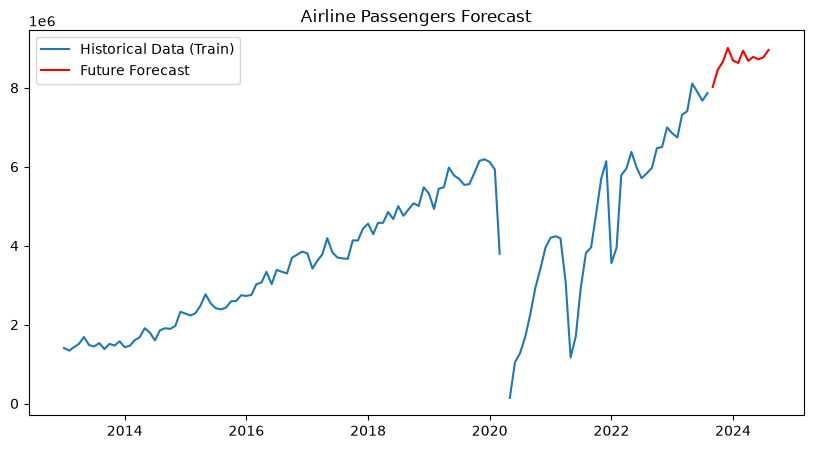

In [9]:
# 3. Train/Test Split
# Since the dataset ends in August 2023, the entire dataset IS our training data!
train = target 

# 4. Modeling - SARIMA (handles seasonality)
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit(disp=False)

# 5. Forecast 12 months into the future (Sep 2023 to Aug 2024)
# You can just tell it how many steps forward to predict
forecast = model_fit.forecast(steps=12)

# 6. Evaluation (Visualizing the forecast)
print("Historical Data vs Future Forecast:")
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Historical Data (Train)')
plt.plot(forecast.index, forecast, label='Future Forecast', color='red')
plt.legend()
plt.title("Airline Passengers Forecast")
plt.show()
